In [1]:
import os
os.chdir('/Users/progressive/Documents/Courses/Final-Year-Disease-Prediction')
print("Working directory:", os.getcwd())

Working directory: /Users/progressive/Documents/Courses/Final-Year-Disease-Prediction


✅ Working directory: /Users/progressive/Documents/Courses/Final-Year-Disease-Prediction
✅ data/processed/era5_nigeria_monthly.csv
✅ data/raw/clean_lassa_fever_map_data.csv

✅ Weather loaded: (88, 5)
        time  year  month  temperature_c  humidity_pct
0 2019-01-01  2019      1      25.529446     37.298670
1 2019-02-01  2019      2      26.721085     36.521160
2 2019-03-01  2019      3      29.648884     42.563084

✅ Lassa loaded: (6, 3)
   year  confirmed_cases  deaths
0  2020             1189     244
1  2021              510     102
2  2022             1067     189
3  2023             1270     227
4  2024             1309     214
5  2025             1148     215

✅ Merged shape: (72, 7)
Years: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

✅ Target created — High risk: 18, Low risk: 54
✅ Final dataset shape: (70, 14)
✅ final_training_data.csv saved!

✅ Class distribution: {0: 52, 1: 18}

=== MODEL EVALUATION (5-Fold Stratified CV) =

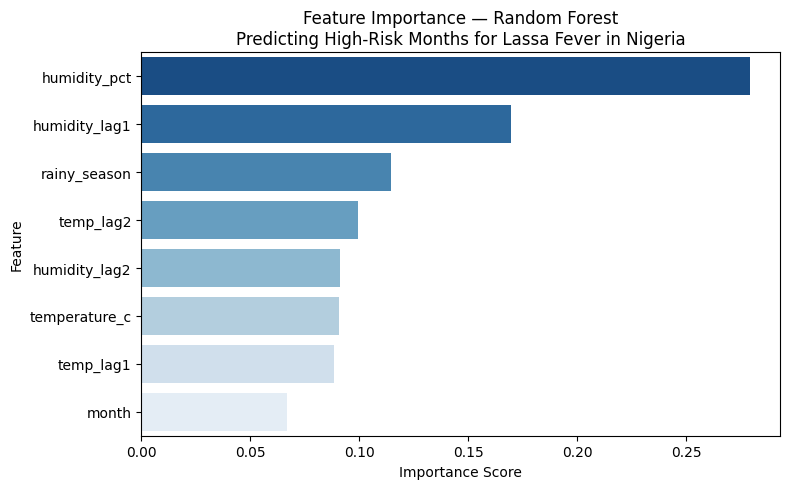

✅ Feature importance chart saved!


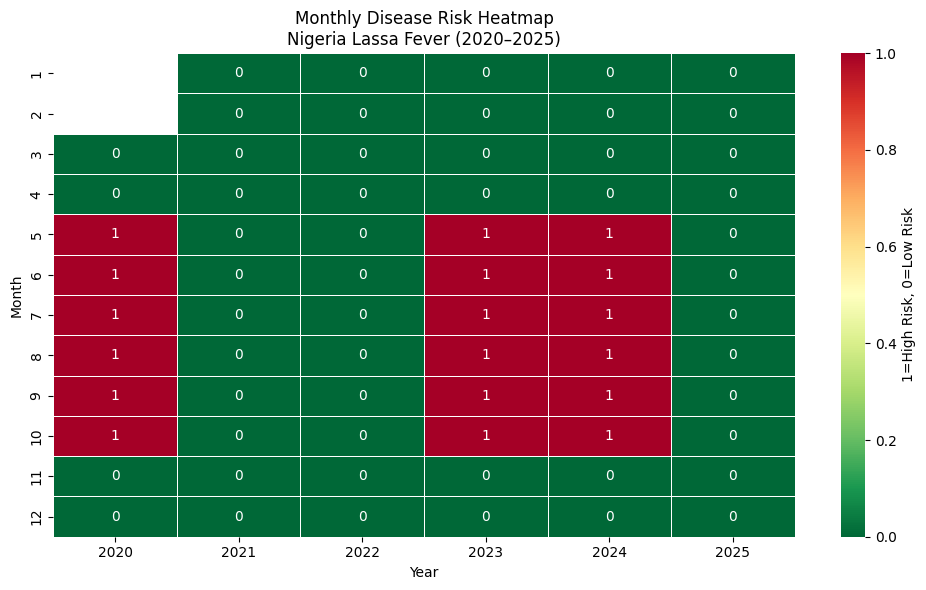

✅ Risk heatmap saved!


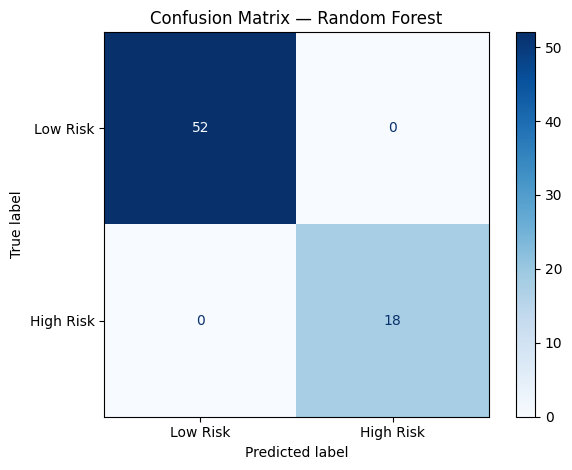

✅ Confusion matrix saved!
✅ Model and scaler saved!

FINAL PROJECT SUMMARY
Dataset:       Nigeria Lassa Fever + ERA5 Weather
Period:        2020–2025
Total samples: 70 monthly observations
Features:      8 weather + seasonal variables
Target:        High-Risk Month (1) vs Low-Risk Month (0)
Severity threshold: 1168 confirmed cases/year

Model Results (5-Fold Stratified CV):

  Logistic Regression:
    Accuracy: 74.29%
    F1 Score: 67.45%
    Recall: 100.00%
    Precision: 52.26%

  Random Forest:
    Accuracy: 64.29%
    F1 Score: 24.76%
    Recall: 30.00%
    Precision: 23.33%

Top weather predictor: humidity_pct (0.2792)
2nd weather predictor: humidity_lag1 (0.1698)
High-risk months identified: 18 of 70
Charts saved to: outputs/figures/


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── 0. Set working directory ───────────────────────────────────────
os.chdir('/Users/progressive/Documents/Courses/Final-Year-Disease-Prediction')
print("✅ Working directory:", os.getcwd())

# ── 1. Verify required files exist ────────────────────────────────
required = [
    'data/processed/era5_nigeria_monthly.csv',
    'data/raw/clean_lassa_fever_map_data.csv'
]
for f in required:
    exists = os.path.exists(f)
    print(f"{'✅' if exists else '❌'} {f}")

# ── 2. Load weather data ───────────────────────────────────────────
df_weather = pd.read_csv('data/processed/era5_nigeria_monthly.csv')
df_weather['time']  = pd.to_datetime(df_weather['time'])
df_weather['year']  = df_weather['time'].dt.year
df_weather['month'] = df_weather['time'].dt.month
print("\n✅ Weather loaded:", df_weather.shape)
print(df_weather.head(3))

# ── 3. Load Lassa data ─────────────────────────────────────────────
df_lassa_raw = pd.read_csv('data/raw/clean_lassa_fever_map_data.csv')
df_lassa_annual = df_lassa_raw.groupby('year').agg(
    confirmed_cases = ('confirmed', 'sum'),
    deaths          = ('deaths',    'sum'),
).reset_index()
print("\n✅ Lassa loaded:", df_lassa_annual.shape)
print(df_lassa_annual)

# ── 4. Merge on year ───────────────────────────────────────────────
df_monthly = pd.merge(df_weather, df_lassa_annual, on='year', how='inner')
print("\n✅ Merged shape:", df_monthly.shape)
print("Years:", sorted(df_monthly['year'].unique()))

# ── 5. Create target variable ──────────────────────────────────────
df_monthly['rainy_season'] = df_monthly['month'].between(5, 10).astype(int)
median_cases = df_monthly['confirmed_cases'].median()
df_monthly['high_severity_year'] = (
    df_monthly['confirmed_cases'] > median_cases
).astype(int)
df_monthly['high_risk'] = (
    (df_monthly['rainy_season'] == 1) &
    (df_monthly['high_severity_year'] == 1)
).astype(int)
print(f"\n✅ Target created — High risk: {df_monthly['high_risk'].sum()}, Low risk: {(df_monthly['high_risk']==0).sum()}")

# ── 6. Add lag features ────────────────────────────────────────────
df_monthly = df_monthly.sort_values(['year','month']).reset_index(drop=True)
df_monthly['temp_lag1']     = df_monthly['temperature_c'].shift(1)
df_monthly['humidity_lag1'] = df_monthly['humidity_pct'].shift(1)
df_monthly['temp_lag2']     = df_monthly['temperature_c'].shift(2)
df_monthly['humidity_lag2'] = df_monthly['humidity_pct'].shift(2)
df_monthly = df_monthly.dropna().reset_index(drop=True)
print("✅ Final dataset shape:", df_monthly.shape)

# ── 7. Save final training data ────────────────────────────────────
os.makedirs('data/processed', exist_ok=True)
df_monthly.to_csv('data/processed/final_training_data.csv', index=False)
print("✅ final_training_data.csv saved!")

# ── 8. Features and target ─────────────────────────────────────────
features = [
    'temperature_c', 'humidity_pct', 'month', 'rainy_season',
    'temp_lag1', 'humidity_lag1', 'temp_lag2', 'humidity_lag2',
]
X = df_monthly[features]
y = df_monthly['high_risk']
print("\n✅ Class distribution:", y.value_counts().to_dict())

# ── 9. Scale features ──────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 10. Train and evaluate models ──────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'Logistic Regression': LogisticRegression(
                               max_iter=1000,
                               class_weight='balanced'
                           ),
    'Random Forest':       RandomForestClassifier(
                               n_estimators=100,
                               random_state=42,
                               class_weight='balanced'
                           ),
}

print("\n=== MODEL EVALUATION (5-Fold Stratified CV) ===")
results = {}
for name, model in models.items():
    acc = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    f1  = cross_val_score(model, X_scaled, y, cv=cv, scoring='f1')
    rec = cross_val_score(model, X_scaled, y, cv=cv, scoring='recall')
    pre = cross_val_score(model, X_scaled, y, cv=cv, scoring='precision')
    results[name] = {
        'Accuracy':  acc.mean(),
        'F1 Score':  f1.mean(),
        'Recall':    rec.mean(),
        'Precision': pre.mean(),
    }
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc.mean():.2%} (+/- {acc.std():.2%})")
    print(f"  F1 Score:  {f1.mean():.2%} (+/- {f1.std():.2%})")
    print(f"  Recall:    {rec.mean():.2%} (+/- {rec.std():.2%})")
    print(f"  Precision: {pre.mean():.2%} (+/- {pre.std():.2%})")

# ── 11. Train final model on all data ─────────────────────────────
rf_final = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight='balanced'
)
rf_final.fit(X_scaled, y)

# ── 12. Feature importance ─────────────────────────────────────────
feat_df = pd.DataFrame({
    'Feature':    features,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n✅ Feature Importance:")
print(feat_df.to_string(index=False))

# ── 13. Save all charts ────────────────────────────────────────────
os.makedirs('outputs/figures', exist_ok=True)

# Feature importance chart
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Feature Importance — Random Forest\nPredicting High-Risk Months for Lassa Fever in Nigeria')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/figures/feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance chart saved!")

# Risk heatmap
pivot = df_monthly.pivot_table(
    values='high_risk', index='month', columns='year', aggfunc='mean'
)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': '1=High Risk, 0=Low Risk'})
plt.title('Monthly Disease Risk Heatmap\nNigeria Lassa Fever (2020–2025)')
plt.xlabel('Year')
plt.ylabel('Month')
plt.tight_layout()
plt.savefig('outputs/figures/risk_heatmap.png', dpi=150)
plt.show()
print("✅ Risk heatmap saved!")

# Confusion matrix
y_pred = rf_final.predict(X_scaled)
ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels=['Low Risk', 'High Risk'],
    cmap='Blues'
)
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.savefig('outputs/figures/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

# ── 14. Save model ─────────────────────────────────────────────────
import joblib
joblib.dump(rf_final, 'outputs/disease_outbreak_model.pkl')
joblib.dump(scaler,   'outputs/scaler.pkl')
print("✅ Model and scaler saved!")

# ── 15. Final summary ──────────────────────────────────────────────
print("\n" + "="*55)
print("FINAL PROJECT SUMMARY")
print("="*55)
print(f"Dataset:       Nigeria Lassa Fever + ERA5 Weather")
print(f"Period:        2020–2025")
print(f"Total samples: {len(df_monthly)} monthly observations")
print(f"Features:      {len(features)} weather + seasonal variables")
print(f"Target:        High-Risk Month (1) vs Low-Risk Month (0)")
print(f"Severity threshold: {median_cases:.0f} confirmed cases/year")
print(f"\nModel Results (5-Fold Stratified CV):")
for name, res in results.items():
    print(f"\n  {name}:")
    for metric, val in res.items():
        print(f"    {metric}: {val:.2%}")
print(f"\nTop weather predictor: {feat_df.iloc[0]['Feature']} ({feat_df.iloc[0]['Importance']:.4f})")
print(f"2nd weather predictor: {feat_df.iloc[1]['Feature']} ({feat_df.iloc[1]['Importance']:.4f})")
print(f"High-risk months identified: {y.sum()} of {len(y)}")
print(f"Charts saved to: outputs/figures/")
print("="*55)